# we created these dicts for 3' data in the finetuning stage

But first make sure the TSS of interest is actually really the one we are interested in

For this see if the canonical TSS is truly the TSS that's the most active by summing the cage values a certain amount around. Use the gtf and set a hyperparameter looking

50 base pairs should be sufficient

In [1]:
#for now start with 50 base pairs!

import json
import pandas as pd

TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep='\t')
tss

,#chr,start,end,name,score,strand,Ensembl_ID,gene_type
0,chr1,35831,36331,FAM138A,0,-,ENSG00000237613,lincRNA
1,chr1,35831,36331,FAM138F,0,-,ENSG00000282591,lincRNA
2,chr1,68840,69340,OR4F5,0,+,ENSG00000186092,protein_coding
3,chr1,817120,817620,FAM87B,0,+,ENSG00000177757,lincRNA
4,chr1,827272,827772,LINC00115,0,-,ENSG00000225880,lincRNA
...,...,...,...,...,...,...,...,...
20662,chrY,21386110,21386610,PRORY,0,-,ENSG00000183146,protein_coding
20663,chrY,21594416,21594916,TTTY13,0,-,ENSG00000184991,lincRNA
20664,chrY,22298626,22299126,TTTY5,0,-,ENSG00000215560,lincRNA
20665,chrY,23198842,23199342,DAZ1,0,-,ENSG00000188120,protein_coding


In [2]:
import re

gtf_path = "/data1/lesliec/sarthak/data/DE_danwei/gencode.v49.annotation.gtf"

gtf = pd.read_csv(
    gtf_path,
    sep="\t",
    comment="#",
    header=None,
    names=[
        "chrom", "source", "feature",
        "start", "end", "score",
        "strand", "frame", "attribute"
    ],
)

def get_attr(attr_str, key):
    m = re.search(fr'{key} "([^"]+)"', attr_str)
    return m.group(1) if m else None

for key in ["gene_id", "transcript_id", "gene_type", "gene_name", "transcript_type"]:
    gtf[key] = gtf["attribute"].apply(lambda s, k=key: get_attr(s, k))

gtf_coding = gtf[gtf['gene_type'] == 'protein_coding']
gtf_coding

,chrom,source,feature,start,end,score,strand,frame,attribute,gene_id,transcript_id,gene_type,gene_name,transcript_type
2486,chr1,HAVANA,gene,65419,71585,.,+,.,"gene_id ""ENSG00000186092.7""; gene_type ""protei...",ENSG00000186092.7,None,protein_coding,OR4F5,None
2487,chr1,HAVANA,transcript,65419,71585,.,+,.,"gene_id ""ENSG00000186092.7""; transcript_id ""EN...",ENSG00000186092.7,ENST00000641515.2,protein_coding,OR4F5,protein_coding
2488,chr1,HAVANA,exon,65419,65433,.,+,.,"gene_id ""ENSG00000186092.7""; transcript_id ""EN...",ENSG00000186092.7,ENST00000641515.2,protein_coding,OR4F5,protein_coding
2489,chr1,HAVANA,exon,65520,65573,.,+,.,"gene_id ""ENSG00000186092.7""; transcript_id ""EN...",ENSG00000186092.7,ENST00000641515.2,protein_coding,OR4F5,protein_coding
2490,chr1,HAVANA,CDS,65565,65573,.,+,0,"gene_id ""ENSG00000186092.7""; transcript_id ""EN...",ENSG00000186092.7,ENST00000641515.2,protein_coding,OR4F5,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7750143,chrM,ENSEMBL,gene,14747,15887,.,+,.,"gene_id ""ENSG00000198727.2""; gene_type ""protei...",ENSG00000198727.2,None,protein_coding,MT-CYB,None
7750144,chrM,ENSEMBL,transcript,14747,15887,.,+,.,"gene_id ""ENSG00000198727.2""; transcript_id ""EN...",ENSG00000198727.2,ENST00000361789.2,protein_coding,MT-CYB,protein_coding
7750145,chrM,ENSEMBL,exon,14747,15887,.,+,.,"gene_id ""ENSG00000198727.2""; transcript_id ""EN...",ENSG00000198727.2,ENST00000361789.2,protein_coding,MT-CYB,protein_coding
7750146,chrM,ENSEMBL,CDS,14747,15887,.,+,0,"gene_id ""ENSG00000198727.2""; transcript_id ""EN...",ENSG00000198727.2,ENST00000361789.2,protein_coding,MT-CYB,protein_coding


In [3]:
tss['main_tss'] = tss['start'] + 250
tss['Ensembl_ID_unversioned'] = tss['Ensembl_ID'].str.split('.').str[0]
tss_dict = tss.set_index('Ensembl_ID_unversioned')['main_tss'].to_dict()
# tss_dict

# 3. Process 'alt_tss' from gtf_coding
# Filter for transcripts to avoid redundant exon/CDS rows
tx_df = gtf_coding[(gtf_coding['feature'] == 'transcript') & 
                   (gtf_coding['transcript_type'] == 'protein_coding')].copy()
tx_df

,chrom,source,feature,start,end,score,strand,frame,attribute,gene_id,transcript_id,gene_type,gene_name,transcript_type
2487,chr1,HAVANA,transcript,65419,71585,.,+,.,"gene_id ""ENSG00000186092.7""; transcript_id ""EN...",ENSG00000186092.7,ENST00000641515.2,protein_coding,OR4F5,protein_coding
6558,chr1,HAVANA,transcript,450740,451678,.,-,.,"gene_id ""ENSG00000284733.2""; transcript_id ""EN...",ENSG00000284733.2,ENST00000426406.4,protein_coding,OR4F29,protein_coding
7173,chr1,HAVANA,transcript,685716,686654,.,-,.,"gene_id ""ENSG00000284662.2""; transcript_id ""EN...",ENSG00000284662.2,ENST00000332831.5,protein_coding,OR4F16,protein_coding
8431,chr1,HAVANA,transcript,923923,944572,.,+,.,"gene_id ""ENSG00000187634.14""; transcript_id ""E...",ENSG00000187634.14,ENST00000968544.1,protein_coding,SAMD11,protein_coding
8464,chr1,HAVANA,transcript,923923,944574,.,+,.,"gene_id ""ENSG00000187634.14""; transcript_id ""E...",ENSG00000187634.14,ENST00000616016.5,protein_coding,SAMD11,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7750109,chrM,ENSEMBL,transcript,10470,10766,.,+,.,"gene_id ""ENSG00000212907.2""; transcript_id ""EN...",ENSG00000212907.2,ENST00000361335.1,protein_coding,MT-ND4L,protein_coding
7750116,chrM,ENSEMBL,transcript,10760,12137,.,+,.,"gene_id ""ENSG00000198886.2""; transcript_id ""EN...",ENSG00000198886.2,ENST00000361381.2,protein_coding,MT-ND4,protein_coding
7750130,chrM,ENSEMBL,transcript,12337,14148,.,+,.,"gene_id ""ENSG00000198786.2""; transcript_id ""EN...",ENSG00000198786.2,ENST00000361567.2,protein_coding,MT-ND5,protein_coding
7750136,chrM,ENSEMBL,transcript,14149,14673,.,-,.,"gene_id ""ENSG00000198695.2""; transcript_id ""EN...",ENSG00000198695.2,ENST00000361681.2,protein_coding,MT-ND6,protein_coding


In [4]:
import numpy as np
tx_df['calc_tss'] = np.where(tx_df['strand'] == '+', tx_df['start'], tx_df['end']) #on plus strand, TSS is start, on minus strand, TSS is end

In [5]:
alt_tss_dict = tx_df.groupby('gene_id')['calc_tss'].apply(lambda x: list(set(x))).to_dict()

In [6]:
import json

with open('/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json', 'r') as f:
    loaded_dict = json.load(f)

loaded_dict

{'ENSG00000186092': {'chrom': 'chr1',
  'counts': 0.0,
  'tss': 69090,
  'alt_tss': [65419],
  'strand': '+'},
 'ENSG00000187634': {'chrom': 'chr1',
  'counts': 1.1043366598147355,
  'tss': 925740,
  'alt_tss': [925731, 930312, 939275, 923923, 923924, 925942, 925150],
  'strand': '+'},
 'ENSG00000188976': {'chrom': 'chr1',
  'counts': 6.783325684813521,
  'tss': 959299,
  'alt_tss': [959244,
   959250,
   959251,
   959256,
   959260,
   959262,
   959263,
   959265,
   959266,
   959267,
   959270,
   959271,
   959276,
   959277,
   959278,
   959283,
   959284,
   959285,
   959286,
   959293,
   959300,
   960714],
  'strand': '-'},
 'ENSG00000187961': {'chrom': 'chr1',
  'counts': 9.189972773359631,
  'tss': 960586,
  'alt_tss': [960576, 960581, 960584, 960585, 960586, 960595, 960599],
  'strand': '+'},
 'ENSG00000187583': {'chrom': 'chr1',
  'counts': 1.5210507369009632,
  'tss': 966496,
  'alt_tss': [966437, 966502, 973512, 966476, 966510, 966482, 966490, 966492],
  'strand': '+

In [7]:
#let's see if the main TSS is even considered a TSS?
tx_df[tx_df['gene_id'] == 'ENSG00000188976.12'].sort_values('calc_tss')

,chrom,source,feature,start,end,score,strand,frame,attribute,gene_id,transcript_id,gene_type,gene_name,transcript_type,calc_tss
8917,chr1,HAVANA,transcript,944203,959244,.,-,.,"gene_id ""ENSG00000188976.12""; transcript_id ""E...",ENSG00000188976.12,ENST00000934953.1,protein_coding,NOC2L,protein_coding,959244
11467,chr1,HAVANA,transcript,944220,959250,.,-,.,"gene_id ""ENSG00000188976.12""; transcript_id ""E...",ENSG00000188976.12,ENST00000934959.1,protein_coding,NOC2L,protein_coding,959250
9603,chr1,HAVANA,transcript,944204,959251,.,-,.,"gene_id ""ENSG00000188976.12""; transcript_id ""E...",ENSG00000188976.12,ENST00000968816.1,protein_coding,NOC2L,protein_coding,959251
8960,chr1,HAVANA,transcript,944203,959251,.,-,.,"gene_id ""ENSG00000188976.12""; transcript_id ""E...",ENSG00000188976.12,ENST00000870737.1,protein_coding,NOC2L,protein_coding,959251
10494,chr1,HAVANA,transcript,944213,959251,.,-,.,"gene_id ""ENSG00000188976.12""; transcript_id ""E...",ENSG00000188976.12,ENST00000968821.1,protein_coding,NOC2L,protein_coding,959251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8874,chr1,HAVANA,transcript,944188,959285,.,-,.,"gene_id ""ENSG00000188976.12""; transcript_id ""E...",ENSG00000188976.12,ENST00000934933.1,protein_coding,NOC2L,protein_coding,959285
9509,chr1,HAVANA,transcript,944203,959286,.,-,.,"gene_id ""ENSG00000188976.12""; transcript_id ""E...",ENSG00000188976.12,ENST00000934934.1,protein_coding,NOC2L,protein_coding,959286
8831,chr1,HAVANA,transcript,943527,959293,.,-,.,"gene_id ""ENSG00000188976.12""; transcript_id ""E...",ENSG00000188976.12,ENST00000870725.1,protein_coding,NOC2L,protein_coding,959293
9552,chr1,HAVANA,transcript,944203,959300,.,-,.,"gene_id ""ENSG00000188976.12""; transcript_id ""E...",ENSG00000188976.12,ENST00000870726.1,protein_coding,NOC2L,protein_coding,959300


# redo for efficiency

## some additional notes

so manyy TSS are close, so based on my boundary, we can just see the relative value around the other TSS after manually setting these to 0 for this... (copy chromosome or read from bigwig each time?)

Then both calculate number of reads of CAGE 

Also exclude chromosome X and Y

In [1]:
#note with the CAGE it is split by 
#minus strand is ENCFF803XET.bigWig, plus strand is ENCFF990ZWH.bigWig

import pandas as pd
import numpy as np
import json

with open('/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json', 'r') as f:
    loaded_dict = json.load(f)
TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep='\t')


import pyBigWig
bw_plus = pyBigWig.open("/data1/lesliec/sarthak/data/DK_zarr/bw_files/ENCFF990ZWH.bigWig")
bw_minus = pyBigWig.open("/data1/lesliec/sarthak/data/DK_zarr/bw_files/ENCFF803XET.bigWig")
#extract chrom lengths from bw_plus
chrom_lengths = bw_plus.chroms()

#read in chr1 from 0 to 10000
np.nan_to_num(bw_plus.values("chr1", 0, 10000))

array([0., 0., 0., ..., 0., 0., 0.])

In [2]:
a='22'
a.isdigit()

True

In [ ]:
#exclude all weird chroms,just standard ones
chrom_lengths = {k: v for k, v in chrom_lengths.items() if k.startswith("chr") and k[3:].isdigit() and int(k[3:]) <= 22}
chrom_lengths

{'chr1': 248956422,
 'chr2': 242193529,
 'chr3': 198295559,
 'chr4': 190214555,
 'chr5': 181538259,
 'chr6': 170805979,
 'chr7': 159345973,
 'chr8': 145138636,
 'chr9': 138394717,
 'chr10': 133797422,
 'chr11': 135086622,
 'chr12': 133275309,
 'chr13': 114364328,
 'chr14': 107043718,
 'chr15': 101991189,
 'chr16': 90338345,
 'chr17': 83257441,
 'chr18': 80373285,
 'chr19': 58617616,
 'chr20': 64444167,
 'chr21': 46709983,
 'chr22': 50818468}

In [6]:
#let's preload the chromosomes into memory
bw_plus_data = {}
bw_minus_data = {}


for chrom, chrom_length in chrom_lengths.items():
    x = np.array(bw_plus.values(chrom, 0, chrom_length), dtype=np.float32)
    y = np.array(bw_minus.values(chrom, 0, chrom_length), dtype=np.float32)
    np.nan_to_num(x, copy=False)
    np.nan_to_num(y, copy=False)
    bw_plus_data[chrom] = x
    bw_minus_data[chrom] = y

In [ ]:
bw_plus_data['chr1'].nbytes/1e9 #1GB for just chr 1 lol

0.995825688

In [9]:
len(bw_plus_data['chr1'])

248956422

In [12]:
#let's see an alt tss
alt_tss_example = loaded_dict['ENSG00000188976']['alt_tss']
alt_tss_example

[959244,
 959250,
 959251,
 959256,
 959260,
 959262,
 959263,
 959265,
 959266,
 959267,
 959270,
 959271,
 959276,
 959277,
 959278,
 959283,
 959284,
 959285,
 959286,
 959293,
 959300,
 960714]

In [ ]:
#now we can go through and test based on the TSSs
length = 50
results = {} # To store your fractions

for gene in loaded_dict.keys():
    main_tss = loaded_dict[gene]['tss']
    alt_tss = loaded_dict[gene]['alt_tss']
    chrom = loaded_dict[gene]['chrom']
    strand = loaded_dict[gene]['strand']
    
    if chrom == 'chrX' or chrom == 'chrY' or chrom == 'chrM':
        continue
    
    # print(f"Gene: {gene}, Chrom: {chrom}, Strand: {strand}, Main TSS: {main_tss}, Alt TSS: {alt_tss}")
    chrom_array = bw_plus_data[chrom] if strand == '+' else bw_minus_data[chrom]
    main_start = max(0, main_tss-length)
    main_end = min(len(chrom_array), main_tss+length)
    vals_main = chrom_array[main_start:main_end].sum()
    
    if len(alt_tss) == 0:
        results[gene] = {'main': vals_main, 'alt': 0, 'fraction': 1.0, 'in_contest': 1.0}
        continue
    # elif len(alt_tss) == 1:
    #     if alt_tss[0] > len(chrom_array):
    #         print('wtf') #2 weird things maybe same gene name but just different? idk man... otherwise it's fine?
    #         results[gene] = {'main': vals_main, 'alt': 0, 'fraction': 1.0}
    #         continue
    
    # 2. Define the Localized Bounding Box for the mask
    min_coord = max(0, min(alt_tss) - length)
    max_coord = min(len(chrom_array), max(alt_tss) + length)
    if min_coord >= max_coord:
        print(f"Invalid coordinates for gene {gene}: min_coord {min_coord} >= max_coord {max_coord}. chromosome length: {len(chrom_array)}, alt_tss: {alt_tss}")
        results[gene] = {'main': vals_main, 'alt': 0, 'fraction': 1.0, 'in_contest': 1.0}
        continue
    span_length = max_coord - min_coord
    
    # Create a small binary mask just for this gene's span
    mask = np.zeros(span_length, dtype=bool)
    
    # 3. Set alternative TSS regions to True in the localized mask
    for alt in alt_tss:
        start_rel = max(0, alt - length) - min_coord
        end_rel = (alt + length) - min_coord #unsure how to set max, I think it will cause issues if longer than span length, but it shouldn't mappen
        # alt_end = min(span_length, alt + length - min_coord)
        mask[start_rel:end_rel] = True
    
    # 4. Set the Canonical TSS region to False to avoid double counting
    main_start_rel = main_start - min_coord
    main_end_rel = main_end - min_coord
    #but only if it overlaps with the alt tss region (s)
    if main_start_rel < span_length and main_end_rel > 0:
        mask[max(0, main_start_rel):min(span_length, main_end_rel)] = False
        
    # 5. Extract the slice and sum using the boolean mask
    alt_slice = chrom_array[min_coord:max_coord]
    vals_alt = alt_slice[mask].sum()
    
    total_signal = vals_main + vals_alt
    fraction = vals_main / total_signal if total_signal > 0 else 1
    
    results[gene] = {'main': vals_main, 'alt': vals_alt, 'fraction': fraction}
    # if gene == 'ENSG00000188976':
    #     print(f"Gene: {gene}, Main TSS Signal: {vals_main}, Alt TSS Signal: {vals_alt}, Fraction: {fraction}")
    #     break

Invalid coordinates for gene ENSG00000177144: min_coord 148748724 >= max_coord 133275309. chromosome length: 133275309, alt_tss: [148748774]
Invalid coordinates for gene ENSG00000122862: min_coord 69088053 >= max_coord 58617616. chromosome length: 58617616, alt_tss: [69088103]


In [16]:
max_coord, min_coord

(133275309, 148748724)

In [ ]:
len(chrom_array) #wtf??

133275309

In [18]:
loaded_dict[gene]

{'chrom': 'chr12',
 'counts': 4.473786911614368,
 'tss': 93377969,
 'alt_tss': [148748774],
 'strand': '+'}

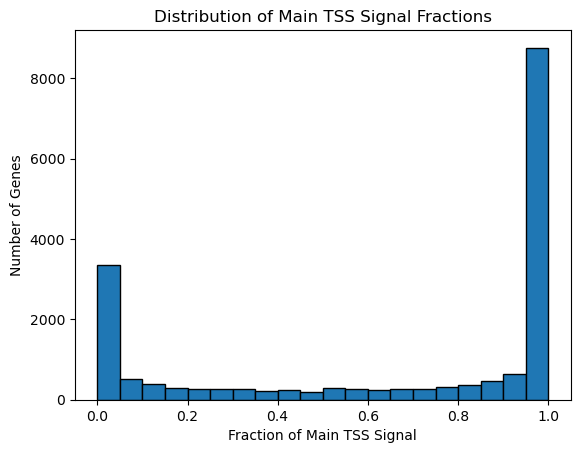

In [24]:
#now let's go ahead and plot the distribution of fractions
import matplotlib.pyplot as plt
fractions = [v['fraction'] for v in results.values()]
plt.hist(fractions, bins=20, edgecolor='black')
plt.title('Distribution of Main TSS Signal Fractions')
plt.xlabel('Fraction of Main TSS Signal')
plt.ylabel('Number of Genes')
plt.show()

In [34]:
#and redo including learning context

context_half_width = 262144  # 524288 / 2
length = 50
results = {} # To store your fractions

for gene in loaded_dict.keys():
    main_tss = loaded_dict[gene]['tss']
    alt_tss = loaded_dict[gene]['alt_tss']
    chrom = loaded_dict[gene]['chrom']
    strand = loaded_dict[gene]['strand']
    
    if chrom == 'chrX' or chrom == 'chrY' or chrom == 'chrM':
        continue
    
    # print(f"Gene: {gene}, Chrom: {chrom}, Strand: {strand}, Main TSS: {main_tss}, Alt TSS: {alt_tss}")
    chrom_array = bw_plus_data[chrom] if strand == '+' else bw_minus_data[chrom]
    main_start = max(0, main_tss-length)
    main_end = min(len(chrom_array), main_tss+length)
    vals_main = chrom_array[main_start:main_end].sum()
    
    if len(alt_tss) == 0:
        results[gene] = {'main': vals_main, 'alt': 0, 'fraction': 1.0, 'in_context': 1.0, 'span_length': 0}
        continue
    # elif len(alt_tss) == 1:
    #     if alt_tss[0] > len(chrom_array):
    #         print('wtf') #2 weird things maybe same gene name but just different? idk man... otherwise it's fine?
    #         results[gene] = {'main': vals_main, 'alt': 0, 'fraction': 1.0}
    #         continue
    
    # 2. Define the Localized Bounding Box for the mask
    min_coord = max(0, min(alt_tss) - length)
    max_coord = min(len(chrom_array), max(alt_tss) + length)
    if min_coord >= max_coord:
        print(f"Invalid coordinates for gene {gene}: min_coord {min_coord} >= max_coord {max_coord}. chromosome length: {len(chrom_array)}, alt_tss: {alt_tss}")
        results[gene] = {'main': vals_main, 'alt': 0, 'fraction': 1.0, 'in_context': 1.0, 'span_length': 0}
        continue
    span_length = max_coord - min_coord
    
    # Create a small binary mask just for this gene's span
    mask = np.zeros(span_length, dtype=bool)
    
    # 3. Set alternative TSS regions to True in the localized mask
    for alt in alt_tss:
        start_rel = max(0, alt - length) - min_coord
        end_rel = (alt + length) - min_coord #unsure how to set max, I think it will cause issues if longer than span length, but it shouldn't mappen
        # alt_end = min(span_length, alt + length - min_coord)
        mask[start_rel:end_rel] = True
    
    # 4. Set the Canonical TSS region to False to avoid double counting
    main_start_rel = main_start - min_coord
    main_end_rel = main_end - min_coord
    #but only if it overlaps with the alt tss region (s)
    if main_start_rel < span_length and main_end_rel > 0:
        mask[max(0, main_start_rel):min(span_length, main_end_rel)] = False
        
    # 5. Extract the slice and sum using the boolean mask
    alt_slice = chrom_array[min_coord:max_coord]
    vals_alt = alt_slice[mask].sum()
    
    # --- NEW IN-CONTEXT LOGIC ---
    # Define absolute context bounds
    context_start = main_tss - context_half_width
    context_end = main_tss + context_half_width
    
    # Translate context bounds to relative mask coordinates
    rel_context_start = max(0, context_start - min_coord)
    rel_context_end = min(span_length, context_end - min_coord)
    
    # Copy the mask and zero out anything outside the context window
    in_context_mask = mask.copy()
    if rel_context_start > 0:
        in_context_mask[:rel_context_start] = False
    if rel_context_end < span_length:
        in_context_mask[rel_context_end:] = False
        
    # Sum only the alt signal that survived the context trimming
    vals_alt_in_context = alt_slice[in_context_mask].sum()
    
    # --- FINAL CALCULATIONS ---
    total_signal = vals_main + vals_alt
    fraction = vals_main / total_signal if total_signal > 0 else 1.0
    
    total_in_context_signal = vals_main + vals_alt_in_context
    in_context = total_in_context_signal / total_signal if total_signal > 0 else 1.0
    
    results[gene] = {
        'main': vals_main, 
        'alt': vals_alt, 
        'fraction': fraction, 
        'in_context': in_context,
        'span_length': span_length
    }
    # if gene == 'ENSG00000188976':
    #     print(f"Gene: {gene}, Main TSS Signal: {vals_main}, Alt TSS Signal: {vals_alt}, Fraction: {fraction}")
    #     break

Invalid coordinates for gene ENSG00000177144: min_coord 148748724 >= max_coord 133275309. chromosome length: 133275309, alt_tss: [148748774]
Invalid coordinates for gene ENSG00000122862: min_coord 69088053 >= max_coord 58617616. chromosome length: 58617616, alt_tss: [69088103]


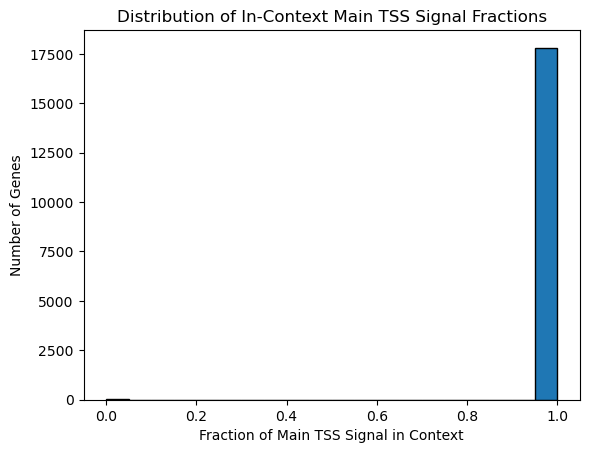

In [ ]:
#ok now let's look at the distribution of in-context fractions
in_context_fractions = [v['in_context'] for v in results.values()]
plt.hist(in_context_fractions, bins=20, edgecolor='black')
plt.title('Distribution of In-Context Main TSS Signal Fractions')
plt.xlabel('Fraction of Main TSS Signal in Context')
plt.ylabel('Number of Genes')
#log the y axxis
# plt.yscale('log')
plt.show()

In [33]:
in_context_fractions = np.array(in_context_fractions)
#find what percent of the data is 1
percent_in_context_1 = np.mean(in_context_fractions == 1.0)
print(f"Percentage of genes with in-context fraction of 1: {percent_in_context_1:.2%}")

Percentage of genes with in-context fraction of 1: 99.62%


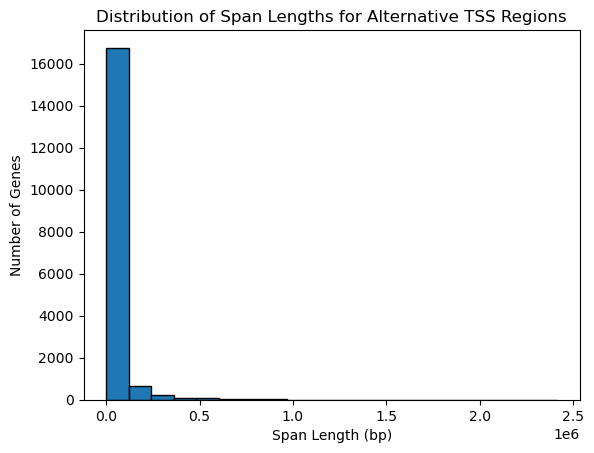

In [37]:
#let's see the distribution of span lengths
span_lengths = [v['span_length'] for v in results.values()]
plt.hist(span_lengths, bins=20, edgecolor='black')
plt.title('Distribution of Span Lengths for Alternative TSS Regions')
plt.xlabel('Span Length (bp)')
plt.ylabel('Number of Genes')
#y axis log
# plt.yscale('log')
plt.show()

## redo but with 128 bp either side

In [57]:
context_half_width = 262144  # 524288 / 2
length = 128
results = {} # To store your fractions

for gene in loaded_dict.keys():
    main_tss = loaded_dict[gene]['tss']
    alt_tss = loaded_dict[gene]['alt_tss']
    chrom = loaded_dict[gene]['chrom']
    strand = loaded_dict[gene]['strand']
    
    if chrom == 'chrX' or chrom == 'chrY' or chrom == 'chrM':
        continue
    
    # print(f"Gene: {gene}, Chrom: {chrom}, Strand: {strand}, Main TSS: {main_tss}, Alt TSS: {alt_tss}")
    chrom_array = bw_plus_data[chrom] if strand == '+' else bw_minus_data[chrom]
    main_start = max(0, main_tss-length)
    main_end = min(len(chrom_array), main_tss+length)
    vals_main = chrom_array[main_start:main_end].sum()
    
    if len(alt_tss) == 0:
        results[gene] = {'main': vals_main, 'alt': 0, 'fraction': 1.0, 'in_context': 1.0, 'span_length': 0}
        continue
    # elif len(alt_tss) == 1:
    #     if alt_tss[0] > len(chrom_array):
    #         print('wtf') #2 weird things maybe same gene name but just different? idk man... otherwise it's fine?
    #         results[gene] = {'main': vals_main, 'alt': 0, 'fraction': 1.0}
    #         continue
    
    # 2. Define the Localized Bounding Box for the mask
    min_coord = max(0, min(alt_tss) - length)
    max_coord = min(len(chrom_array), max(alt_tss) + length)
    if min_coord >= max_coord:
        print(f"Invalid coordinates for gene {gene}: min_coord {min_coord} >= max_coord {max_coord}. chromosome length: {len(chrom_array)}, alt_tss: {alt_tss}")
        results[gene] = {'main': vals_main, 'alt': 0, 'fraction': 1.0, 'in_context': 1.0, 'span_length': 0}
        continue
    span_length = max_coord - min_coord
    
    # Create a small binary mask just for this gene's span
    mask = np.zeros(span_length, dtype=bool)
    
    # 3. Set alternative TSS regions to True in the localized mask
    for alt in alt_tss:
        start_rel = max(0, alt - length) - min_coord
        end_rel = (alt + length) - min_coord #unsure how to set max, I think it will cause issues if longer than span length, but it shouldn't mappen
        # alt_end = min(span_length, alt + length - min_coord)
        mask[start_rel:end_rel] = True
    
    # 4. Set the Canonical TSS region to False to avoid double counting
    main_start_rel = main_start - min_coord
    main_end_rel = main_end - min_coord
    #but only if it overlaps with the alt tss region (s)
    if main_start_rel < span_length and main_end_rel > 0:
        mask[max(0, main_start_rel):min(span_length, main_end_rel)] = False
        
    # 5. Extract the slice and sum using the boolean mask
    alt_slice = chrom_array[min_coord:max_coord]
    vals_alt = alt_slice[mask].sum()
    
    # --- NEW IN-CONTEXT LOGIC ---
    # Define absolute context bounds
    context_start = main_tss - context_half_width
    context_end = main_tss + context_half_width
    
    # Translate context bounds to relative mask coordinates
    rel_context_start = max(0, context_start - min_coord)
    rel_context_end = min(span_length, context_end - min_coord)
    
    # Copy the mask and zero out anything outside the context window
    in_context_mask = mask.copy()
    if rel_context_start > 0:
        in_context_mask[:rel_context_start] = False
    if rel_context_end < span_length:
        in_context_mask[rel_context_end:] = False
        
    # Sum only the alt signal that survived the context trimming
    vals_alt_in_context = alt_slice[in_context_mask].sum()
    
    # --- FINAL CALCULATIONS ---
    total_signal = vals_main + vals_alt
    fraction = vals_main / total_signal if total_signal > 0 else 1.0
    
    total_in_context_signal = vals_main + vals_alt_in_context
    in_context = total_in_context_signal / total_signal if total_signal > 0 else 1.0
    
    results[gene] = {
        'main': vals_main, 
        'alt': vals_alt, 
        'fraction': fraction, 
        'in_context': in_context,
        'span_length': span_length
    }
    # if gene == 'ENSG00000188976':
    #     print(f"Gene: {gene}, Main TSS Signal: {vals_main}, Alt TSS Signal: {vals_alt}, Fraction: {fraction}")
    #     break

Invalid coordinates for gene ENSG00000177144: min_coord 148748646 >= max_coord 133275309. chromosome length: 133275309, alt_tss: [148748774]
Invalid coordinates for gene ENSG00000122862: min_coord 69087975 >= max_coord 58617616. chromosome length: 58617616, alt_tss: [69088103]


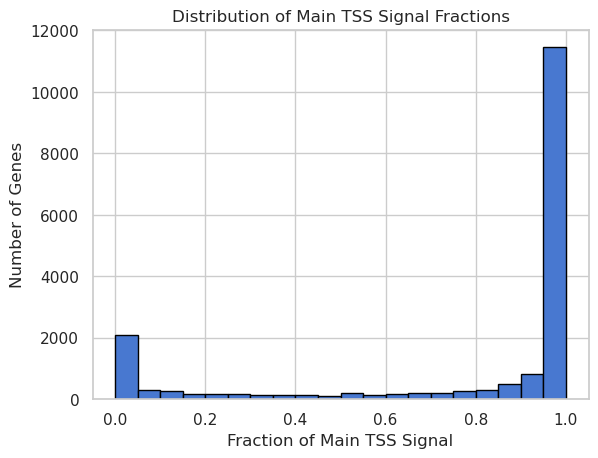

In [58]:
#and let's plot
fractions = [v['fraction'] for v in results.values()]
plt.hist(fractions, bins=20, edgecolor='black')
plt.title('Distribution of Main TSS Signal Fractions')
plt.xlabel('Fraction of Main TSS Signal')
plt.ylabel('Number of Genes')
plt.show()

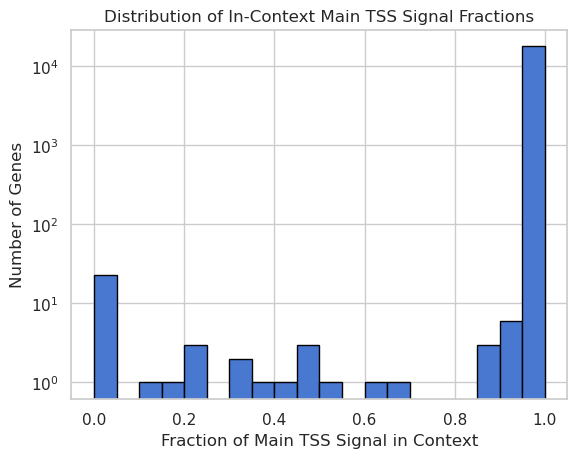

In [59]:
in_context_fractions = [v['in_context'] for v in results.values()]
plt.hist(in_context_fractions, bins=20, edgecolor='black')
plt.title('Distribution of In-Context Main TSS Signal Fractions')
plt.xlabel('Fraction of Main TSS Signal in Context')
plt.ylabel('Number of Genes')
#log the y axxis
plt.yscale('log')
plt.show()

# some additional visualizations

In [43]:
#let's now just use the sc and bulk data to see if we can do some 2d histogram

import json
with open('/data1/lesliec/sarthak/data/DE_danwei/k562_sc_rna_info.json', 'r') as f:
    sc_loaded_dict = json.load(f)
#and bulk
with open('/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json', 'r') as f:
    bulk_loaded_dict = json.load(f)
print(f"Number of genes in sc_loaded_dict: {len(sc_loaded_dict)}")
print(f"Number of genes in bulk_loaded_dict: {len(bulk_loaded_dict)}")

Number of genes in sc_loaded_dict: 18628
Number of genes in bulk_loaded_dict: 18628


In [44]:
#now let's get arrays
bulk_counts = []
sc_counts = []
for gene in bulk_loaded_dict.keys():
    bulk_counts.append(bulk_loaded_dict[gene]['counts'])
    sc_counts.append(sc_loaded_dict[gene]['counts'])
#and make them np arrays
bulk_counts = np.array(bulk_counts)
sc_counts = np.array(sc_counts)

/tmp/ipykernel_2773207/194339563.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Type', y='Count', palette=colors, inner="quartile", ax=ax4)


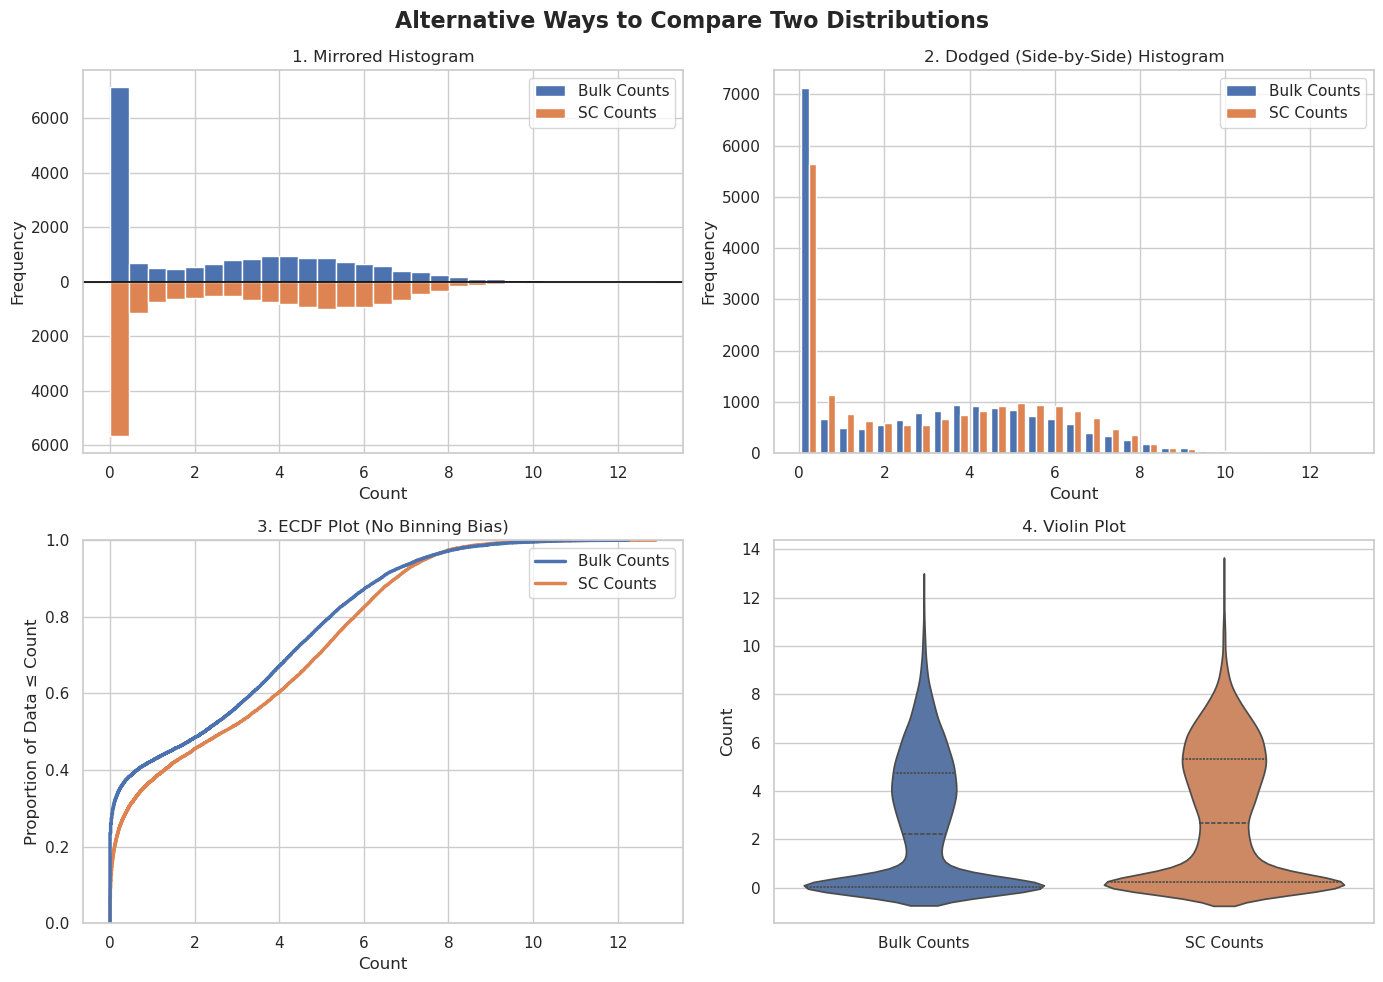

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import FuncFormatter

# ---------------------------------------------------------
# 1. Generate Dummy Data (Replace with your actual arrays)
# ---------------------------------------------------------
np.random.seed(42)
# Simulating some count data (e.g., RNA-seq or similar)
# bulk_counts = np.random.negative_binomial(n=20, p=0.5, size=1500)
# sc_counts = np.random.negative_binomial(n=12, p=0.4, size=1500)

# ---------------------------------------------------------
# Setup & Styling
# ---------------------------------------------------------
sns.set_theme(style="whitegrid", palette="muted")
colors = ["#4C72B0", "#DD8452"] # Blue for Bulk, Orange for SC

# Find common bins for fair comparison
min_val = min(bulk_counts.min(), sc_counts.min())
max_val = max(bulk_counts.max(), sc_counts.max())
common_bins = np.linspace(min_val, max_val, 30)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Alternative Ways to Compare Two Distributions", fontsize=16, fontweight='bold')

# =========================================================
# Method 1: Mirrored Histogram (Top-Bottom)
# =========================================================
ax1 = axes[0, 0]
# Plot Bulk pointing up
ax1.hist(bulk_counts, bins=common_bins, color=colors[0], edgecolor='white', label='Bulk Counts')
# Plot SC pointing down by using negative weights
ax1.hist(sc_counts, bins=common_bins, color=colors[1], edgecolor='white', 
         weights=-np.ones_like(sc_counts), label='SC Counts')

# Add a horizontal line at 0
ax1.axhline(0, color='black', linewidth=1.2)

# Make y-axis labels absolute (so we don't see negative counts)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(int(x))}"))
ax1.set_title("1. Mirrored Histogram")
ax1.set_xlabel("Count")
ax1.set_ylabel("Frequency")
ax1.legend()

# =========================================================
# Method 2: Dodged (Side-by-Side) Histogram
# =========================================================
ax2 = axes[0, 1]
ax2.hist([bulk_counts, sc_counts], bins=common_bins, color=colors, 
         label=['Bulk Counts', 'SC Counts'], edgecolor='white')

ax2.set_title("2. Dodged (Side-by-Side) Histogram")
ax2.set_xlabel("Count")
ax2.set_ylabel("Frequency")
ax2.legend()

# =========================================================
# Method 3: ECDF Plot (Empirical Cumulative Distribution)
# =========================================================
ax3 = axes[1, 0]
# ECDF is highly recommended because it has no binning bias
sns.ecdfplot(data={'Bulk Counts': bulk_counts, 'SC Counts': sc_counts}, 
             palette=colors, linewidth=2.5, ax=ax3)

ax3.set_title("3. ECDF Plot (No Binning Bias)")
ax3.set_xlabel("Count")
ax3.set_ylabel("Proportion of Data \u2264 Count")

# =========================================================
# Method 4: Violin Plot (Density Distribution)
# =========================================================
ax4 = axes[1, 1]
# Data wrangling for seaborn categorical plotting
df = pd.DataFrame({
    'Count': np.concatenate([bulk_counts, sc_counts]),
    'Type': ['Bulk Counts']*len(bulk_counts) + ['SC Counts']*len(sc_counts)
})

sns.violinplot(data=df, x='Type', y='Count', palette=colors, inner="quartile", ax=ax4)
ax4.set_title("4. Violin Plot")
ax4.set_xlabel("")
ax4.set_ylabel("Count")

# ---------------------------------------------------------
# Finalizing and Showing the Plot
# ---------------------------------------------------------
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Adjust for the suptitle
plt.show()

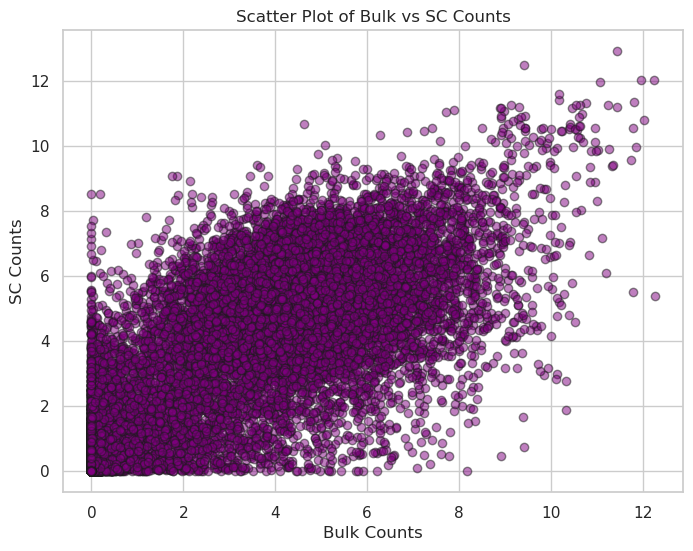

In [46]:
#let's do a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(bulk_counts, sc_counts, alpha=0.5, color='purple', edgecolor='k')
plt.title("Scatter Plot of Bulk vs SC Counts")
plt.xlabel("Bulk Counts")
plt.ylabel("SC Counts")
plt.show()